**Disclaimer**: This project is for educational and portfolio purposes only. The results generated—including the 1.17 Sharpe Ratio—are based on historical data and do not constitute financial advice or a recommendation to buy or sell any securities.

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
stock_list = ['ITC.NS',
              'VBL.NS',
              'TATACONSUM.NS',
              'ICICIBANK.NS',
              'HDFCBANK.NS',
              'RELIANCE.NS',
              'HINDUNILVR.NS']

stocks = {}

for stock in stock_list:
    stocks[stock] = pd.DataFrame(yf.download(stock, period='10Y', auto_adjust=True)['Close'])
print("Loaded data...")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Loaded data...


In [3]:
stocks_df = pd.concat(stocks.values(), axis=1).dropna()
stocks_df.head()

Ticker,ITC.NS,VBL.NS,TATACONSUM.NS,ICICIBANK.NS,HDFCBANK.NS,RELIANCE.NS,HINDUNILVR.NS
Date,,,,,,,
2016-11-08,176.188889,26.450884,115.866508,245.366577,290.719604,219.890518,732.534973
2016-11-09,171.053513,25.003136,110.820930,243.850357,290.012634,220.131546,718.397888
2016-11-10,173.052536,25.118265,114.002831,253.510788,296.340210,221.402496,709.941589
2016-11-11,167.469070,25.365793,107.866325,239.475021,295.702759,219.507065,695.370605
2016-11-15,163.712311,25.219004,106.366272,233.713394,290.823853,215.924408,698.579773


In [4]:
stock_returns = stocks_df.pct_change()
stock_returns

Ticker,ITC.NS,VBL.NS,TATACONSUM.NS,ICICIBANK.NS,HDFCBANK.NS,RELIANCE.NS,HINDUNILVR.NS
Date,,,,,,,
2016-11-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-11-09,-0.029147,-0.054733,-0.043546,-0.006179,-0.002432,0.001096,-0.019299
2016-11-10,0.011687,0.004605,0.028712,0.039616,0.021818,0.005774,-0.011771
2016-11-11,-0.032265,0.009855,-0.053828,-0.055366,-0.002151,-0.008561,-0.020524
2016-11-15,-0.022433,-0.005787,-0.013907,-0.024059,-0.016499,-0.016321,0.004615
...,...,...,...,...,...,...,...
2026-04-17,0.011206,0.029322,0.009614,0.000966,0.005594,0.016154,0.047543
2026-04-20,-0.005867,-0.015510,0.006468,0.006979,-0.005563,-0.001245,-0.004150
2026-04-21,0.015246,0.039760,0.019279,0.023743,0.020492,-0.007335,0.035492


In [5]:
risk_free_rate = 6.6/100
scenarios = 10000

weights_array = np.zeros((scenarios,len(stock_returns.columns)))
returns_array = np.zeros(scenarios)
volatility_array = np.zeros(scenarios)
sharpe_array = np.zeros(scenarios)

In [6]:
np.random.seed(10)

for index in range(scenarios):
    # Generate four random numbers for each index
    rand_nums = np.random.random(len(stock_returns.columns))
    
    # Divide each number by the sum of the numbers to generate the random weight
    rand_weights = rand_nums / sum(rand_nums)
    
    # Save the weights in weights_array
    weights_array[index,:] = rand_weights
        
    # Calculate the return for each scenario
    returns_array[index] = np.sum(stock_returns.mean()*252*rand_weights)
    
    # Calculate the expected volatility for each scenario
    volatility_array[index] = np.sqrt(np.dot(rand_weights.T,np.dot(stock_returns.cov()*252, rand_weights)))

        
    # Calculate the Sharpe Ratio for each scenario 
    sharpe_array[index] = (returns_array[index] - risk_free_rate) / volatility_array[index]

print("The first combination:", weights_array[0])
print("The sharpe ratio of the first portfolio:", sharpe_array[0])

The first combination: [0.24914333 0.00670306 0.20467393 0.24187022 0.16102213 0.07261129
 0.06397604]
The sharpe ratio of the first portfolio: 0.6816662753313638


In [7]:
index_max_sharpe = sharpe_array.argmax()

print(f"{'Stock Name':<30} {'Weight (%)':>20}")
print("-"*52)

for i, stock in enumerate(stock_list):
    print(f'{yf.Ticker(stock).info.get('longName'):<30} {round(weights_array[index_max_sharpe, i]*100, 4):>20.4f}%')

Stock Name                               Weight (%)
----------------------------------------------------
ITC Limited                                  1.0740%
Varun Beverages Limited                     39.5150%
Tata Consumer Products Limited              23.7425%
ICICI Bank Limited                          11.0580%
HDFC Bank Limited                            1.6491%
Reliance Industries Limited                 22.0737%
Hindustan Unilever Limited                   0.8877%


In [8]:
sharpe_array.max()

np.float64(1.1174026880077286)

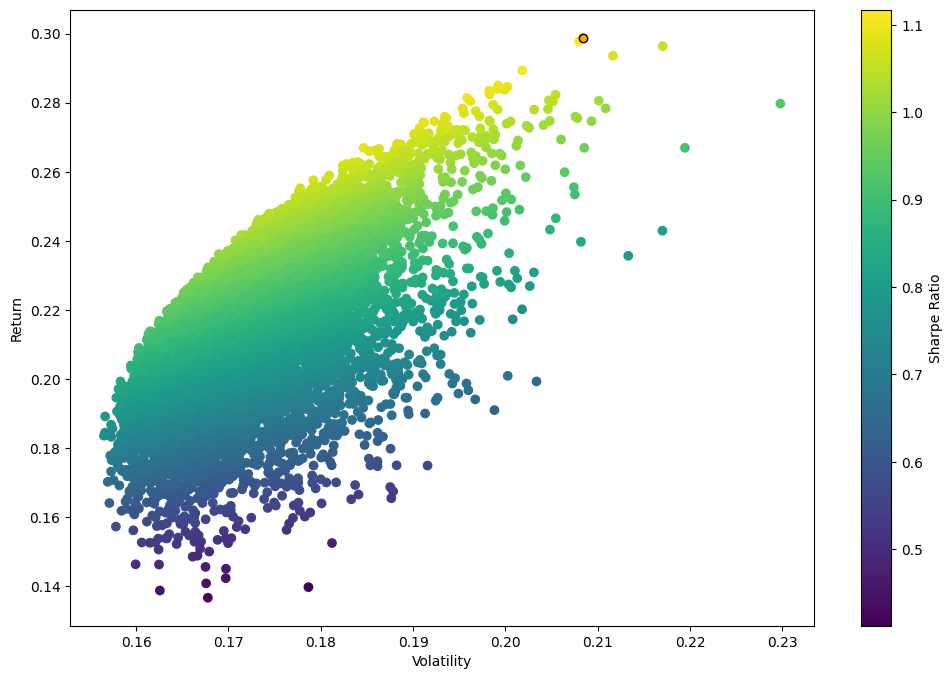

In [9]:
# Identify the optimal portfolio in the returns and volatility arrays
max_sharpe_return = returns_array[index_max_sharpe]
max_sharpe_volatility = volatility_array[index_max_sharpe]

# Visualize volatility vs returns for each scenario
plt.figure(figsize=(12,8))

plt.scatter(volatility_array, returns_array, c=sharpe_array, cmap='viridis')

plt.colorbar(label='Sharpe Ratio')
plt.xlabel('Volatility')
plt.ylabel('Return')


# Add the optimal portfolio to the visual
plt.scatter(max_sharpe_volatility, max_sharpe_return, c='orange', edgecolors='black')

plt.savefig('efficient_frontier.png', dpi=150, bbox_inches='tight')
plt.show()